In [1]:
import numpy as np
import matplotlib.pyplot as plt

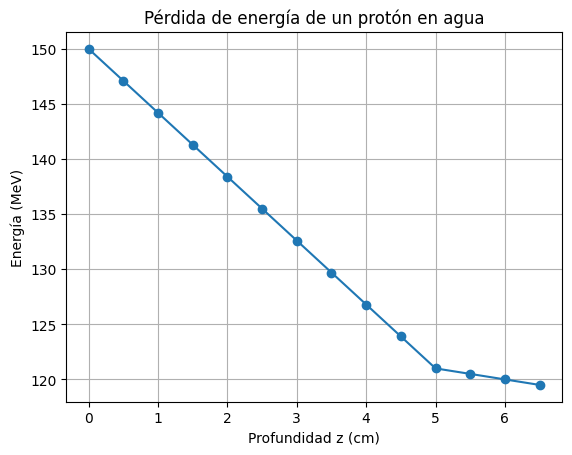

In [2]:
# Datos (z en cm, energía en MeV)
z = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5])
E = np.array([150.0, 147.1, 144.2, 141.3, 138.4, 135.5, 132.6, 129.7, 126.8, 123.9, 121.0, 120.5, 120.0, 119.5])

plt.figure()
plt.plot(z, E, marker='o')

plt.xlabel("Profundidad z (cm)")
plt.ylabel("Energía (MeV)")
plt.title("Pérdida de energía de un protón en agua")

plt.grid()
plt.show()

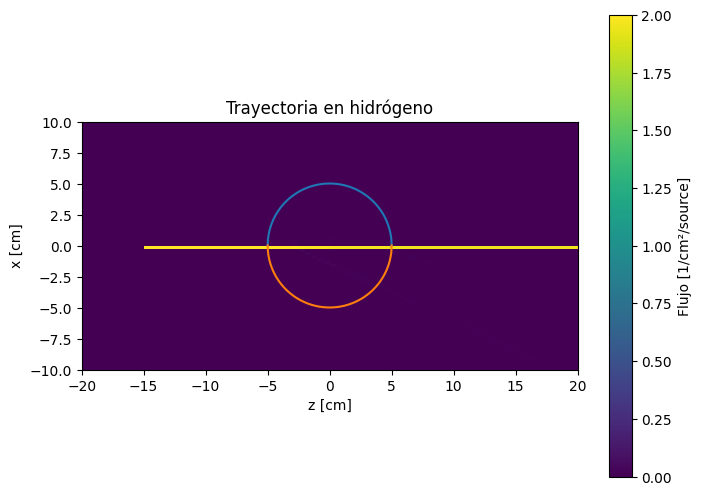

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import re

with open("track_hidrogeno.out", "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

zmin = float(re.search(r"xmin\(\s*([-\d.E+]+)", text).group(1))
zmax = float(re.search(r"xmax\(\s*([-\d.E+]+)", text).group(1))
xmin = float(re.search(r"ymin\(\s*([-\d.E+]+)", text).group(1))
xmax = float(re.search(r"ymax\(\s*([-\d.E+]+)", text).group(1))
nx = int(re.search(r"#\s*nx\s*=\s*(\d+)", text).group(1))
nz = int(re.search(r"#\s*nx\s*=\s*\d+\s*nz\s*=\s*(\d+)", text).group(1))

start = text.index("hc:")
lines = text[start:].splitlines()[1:]

vals = []
for line in lines:
    if line.strip().startswith("#") or not line.strip():
        continue
    nums = re.findall(r"[-+]?\d+\.\d+E[+-]\d+", line)
    vals.extend(float(n) for n in nums)

data = np.array(vals[:nx * nz]).reshape(nx, nz)

z_edges = np.linspace(zmin, zmax, nz + 1)
x_edges = np.linspace(xmin, xmax, nx + 1)

plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(z_edges, x_edges, data, shading="auto")
plt.colorbar(pcm, label="Flujo [1/cm²/source]")

z = np.linspace(-5, 5, 400)
x_top = np.sqrt(25 - z**2)
x_bot = -np.sqrt(25 - z**2)
plt.plot(z, x_top)
plt.plot(z, x_bot)

plt.xlabel("z [cm]")
plt.ylabel("x [cm]")
plt.title("Trayectoria en hidrógeno")
plt.xlim(zmin, zmax)
plt.ylim(xmin, xmax)
plt.gca().set_aspect("equal")
plt.show()